# Classifying Fashion-MNIST

Now it's your turn to build and train a neural network. You'll be using the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist), a drop-in replacement for the MNIST dataset. MNIST is actually quite trivial with neural networks where you can easily achieve better than 97% accuracy. Fashion-MNIST is a set of 28x28 greyscale images of clothes. It's more complex than MNIST, so it's a better representation of the actual performance of your network, and a better representation of datasets you'll use in the real world.

<img src='assets/fashion-mnist-sprite.png' width=500px>

In this notebook, you'll build your own neural network. For the most part, you could just copy and paste the code from Part 3, but you wouldn't be learning. It's important for you to write the code yourself and get it to work. Feel free to consult the previous notebook though as you work through this.

First off, let's load the dataset through torchvision.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import OrderedDict

import numpy as np

import torch
from torch import nn
from torch import optim
from torchvision import datasets, transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import os

import helper

In [2]:
# --- PREPROCESAMIENTO ---
data_dir = 'dataset'

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
trainset, testset = random_split(full_dataset, [train_size, test_size])

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"Total de imágenes: {len(full_dataset)}")
print(f"Train: {len(trainset)} | Test: {len(testset)}")

Total de imágenes: 38380
Train: 30704 | Test: 7676


Here we can see one of the images.

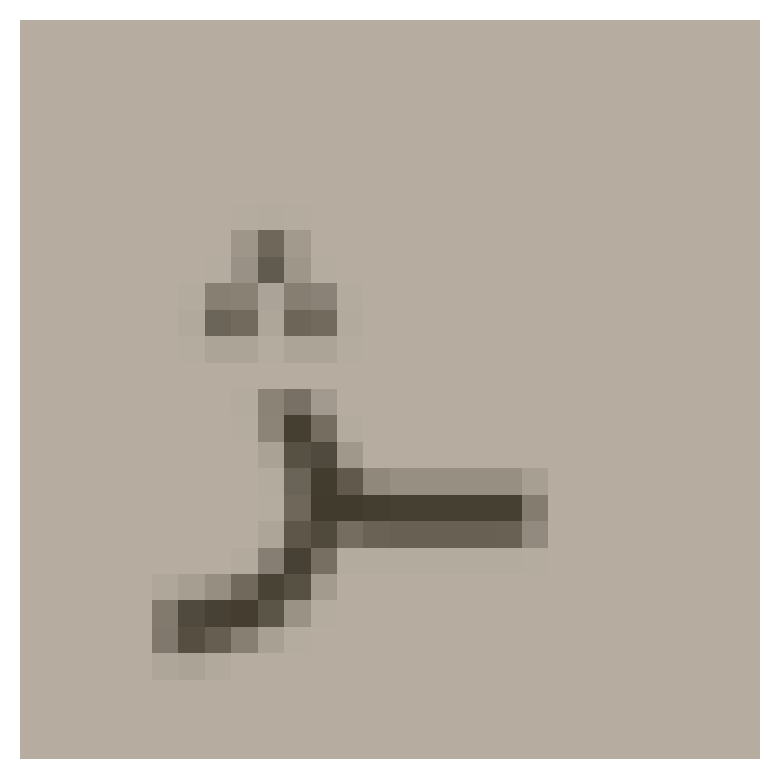

In [3]:
image, label = next(iter(trainloader))
helper.imshow(image[0,:]);

## Building the network

Here you should define your network. As with MNIST, each image is 28x28 which is a total of 784 pixels, and there are 10 classes. You should include at least one hidden layer. We suggest you use ReLU activations for the layers and to return the logits from the forward pass. It's up to you how many layers you add and the size of those layers.

In [4]:
# --- VERIFICAR DISPONIBILIDAD DE GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🟢 Entrenando en: {device}")

🟢 Entrenando en: cuda


In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
import torch.nn as nn
from collections import OrderedDict

input_size = 784
hidden_sizes = [256, 128]   # <- mejor configuración para Fashion-MNIST
output_size = 101
drop_p = 0.4

model = nn.Sequential(OrderedDict([
    ('fc1', nn.Linear(input_size, hidden_sizes[0])),
    ('bn1', nn.BatchNorm1d(hidden_sizes[0])),
    ('relu1', nn.ReLU()),
    ('dropout1', nn.Dropout(p=drop_p)),

    ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
    ('bn2', nn.BatchNorm1d(hidden_sizes[1])),
    ('relu2', nn.ReLU()),
    ('dropout2', nn.Dropout(p=drop_p)),


    ('logits', nn.Linear(hidden_sizes[1], output_size))
]))

model.to(device)


Sequential(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.4, inplace=False)
  (logits): Linear(in_features=128, out_features=101, bias=True)
)

# Train the network

Now you should create your network and train it. First you'll want to define [the criterion](http://pytorch.org/docs/master/nn.html#loss-functions) ( something like `nn.CrossEntropyLoss`) and [the optimizer](http://pytorch.org/docs/master/optim.html) (typically `optim.SGD` or `optim.Adam`).

Then write the training code. Remember the training pass is a fairly straightforward process:

* Make a forward pass through the network to get the logits 
* Use the logits to calculate the loss
* Perform a backward pass through the network with `loss.backward()` to calculate the gradients
* Take a step with the optimizer to update the weights

By adjusting the hyperparameters (hidden units, learning rate, etc), you should be able to get the training loss below 0.4.

In [8]:
# # --- CARGAR PESOS SI EXISTEN ---
model_path = "model_persian_chars_v1.pth"

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("✅ Modelo cargado desde archivo existente.")
else:
    print("⚠️ No se encontró modelo previo. Entrenando desde cero.")

✅ Modelo cargado desde archivo existente.


C:\Users\mark_\AppData\Local\Temp\ipykernel_31984\110608801.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

In [8]:
# TODO: Create the network, define the criterion and optimizer
# --- CRITERIO Y OPTIMIZADOR ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9)

# Scheduler: reduce el LR a la mitad después de 10 épocas
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [9]:
# --- ENTRENAMIENTO ---
epochs = 25
print_every = 40
steps = 0


model.train()
for e in range(epochs):
    running_loss = 0

    for images, labels in trainloader:
        steps += 1

        # Mover tensores a GPU
        images = images.to(device)
        labels = labels.to(device)

        # Aplanar imágenes
        images = images.reshape(images.size(0), -1)

        optimizer.zero_grad()

        # Forward pass
        output = model(images)
        loss = criterion(output, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print
        if steps % print_every == 0:
            print(f"Epoch {e+1}/{epochs} | "
                  f"Loss: {running_loss/print_every:.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.5f}")
            running_loss = 0

    # <-- MUY IMPORTANTE: bajar lr al terminar cada época
    scheduler.step()


Epoch 1/25 | Loss: 4.0110 | LR: 0.02000
Epoch 1/25 | Loss: 2.8289 | LR: 0.02000
Epoch 1/25 | Loss: 2.1658 | LR: 0.02000
Epoch 1/25 | Loss: 1.8241 | LR: 0.02000
Epoch 1/25 | Loss: 1.6968 | LR: 0.02000
Epoch 1/25 | Loss: 1.6267 | LR: 0.02000
Epoch 1/25 | Loss: 1.5428 | LR: 0.02000
Epoch 1/25 | Loss: 1.4748 | LR: 0.02000
Epoch 1/25 | Loss: 1.4534 | LR: 0.02000
Epoch 1/25 | Loss: 1.3529 | LR: 0.02000
Epoch 1/25 | Loss: 1.2916 | LR: 0.02000
Epoch 1/25 | Loss: 1.2701 | LR: 0.02000
Epoch 2/25 | Loss: 1.2339 | LR: 0.02000
Epoch 2/25 | Loss: 1.1311 | LR: 0.02000
Epoch 2/25 | Loss: 1.1348 | LR: 0.02000
Epoch 2/25 | Loss: 1.1311 | LR: 0.02000
Epoch 2/25 | Loss: 1.1427 | LR: 0.02000
Epoch 2/25 | Loss: 1.1654 | LR: 0.02000
Epoch 2/25 | Loss: 1.1247 | LR: 0.02000
Epoch 2/25 | Loss: 1.1107 | LR: 0.02000
Epoch 2/25 | Loss: 1.0565 | LR: 0.02000
Epoch 2/25 | Loss: 1.0254 | LR: 0.02000
Epoch 2/25 | Loss: 0.9817 | LR: 0.02000
Epoch 2/25 | Loss: 1.0177 | LR: 0.02000
Epoch 3/25 | Loss: 0.9465 | LR: 0.02000


In [9]:
# Accuracy en test
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images.view(images.size(0), -1))
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test: {100 * correct / total:.2f}%')


Test: 93.68%


In [ ]:
# Accuracy en train
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images.view(images.size(0), -1))
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Entrenamiento: {100 * correct / total:.2f}%')


In [13]:
# --- GUARDAR MODELO ---
model_path = "model_persian_chars_V1.pth"

torch.save(model.state_dict(), model_path)
print("💾 Modelo guardado correctamente.")

💾 Modelo guardado correctamente.


___

In [32]:
# --- EVALUACIÓN / PREDICCIÓN (Optimizada) ---
model.eval()

# Crear el iterador solo una vez (fuera de ciclos)
if 'dataiter' not in locals():
    dataiter = iter(trainloader)
    

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (101,) and arg 3 with shape (10,).

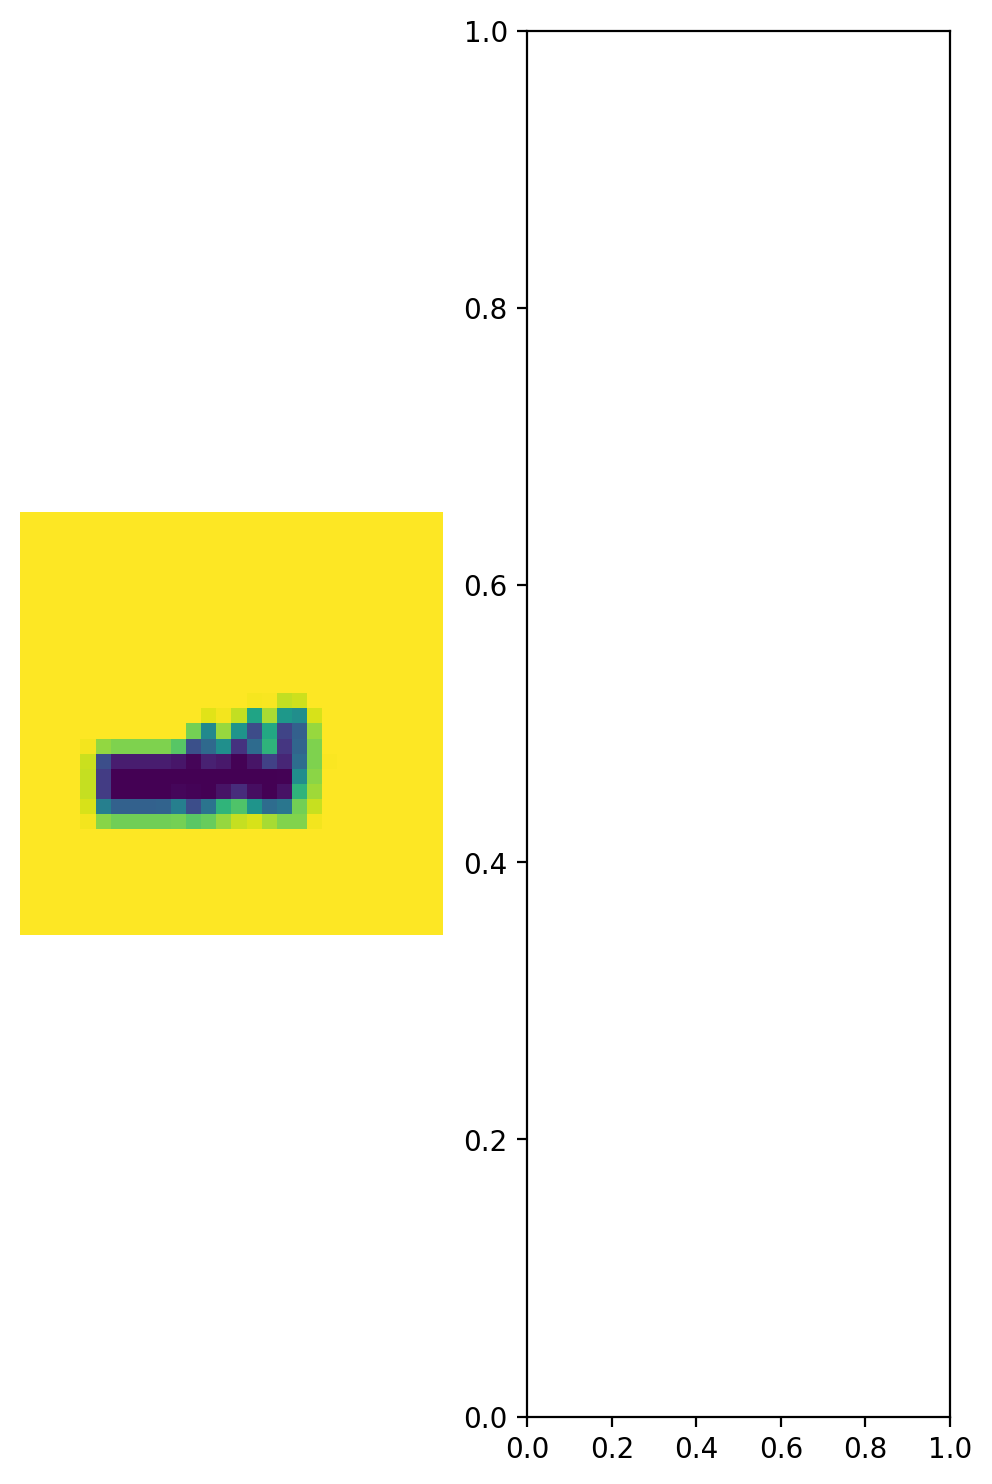

In [37]:

# Obtener un batch (solo si no hay otro pendiente)
try:
    images, labels = next(dataiter)
except StopIteration:
    dataiter = iter(trainloader)
    images, labels = next(dataiter)

# Seleccionar una imagen (sin volver a transformar todo el batch)
img = images[0].unsqueeze(0).view(1, 784).to(device)

# Desactivar gradientes para evaluación
with torch.no_grad():
    logits = model(img)

# Calcular probabilidades
ps = F.softmax(logits, dim=1)

# Mostrar imagen y predicción
helper.view_classify(images[0].view(1, 28, 28).cpu(), ps.cpu())


Now that your network is trained, you'll want to save it to disk so you can load it later instead of training it again. Obviously, it's impractical to train a network every time you need one. In practice, you'll train it once, save the model, then reload it for further training or making predictions. In the next part, I'll show you how to save and load trained models.